# Diabetes Risk Prediction from Health-Survey Data

**Seminar:** Advanced Applied Data Science  
**Institution:** Goethe University Frankfurt  
**Term:** Summer Semester 2026  
**Supervisor:** Prof. Dr. Kevin Bauer  
**Group:** Diabetes Prediction  

**Dataset:** CDC BRFSS 2015 — Diabetes Health Indicators  
[UCI ML Repository · Dataset #891](https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators)

---

## Team

- Hasher Malik — 7632048
- Jan Erdorf — 8748557
- Ilias El Ouali — 000001
- Sophia Schaal — 7229428

---

## Project Overview

This project builds a binary classifier that predicts diabetes risk from self-reported health and lifestyle survey responses collected in the CDC BRFSS 2015 dataset. The goal is to support public-health screening programs by identifying high-risk individuals for follow-up clinical testing — without requiring laboratory results. The project follows the **Cross-Industry Standard Process for Data Mining (CRISP-DM)**, progressing through business understanding, data exploration, preparation, modelling, and evaluation in a structured, iterative fashion.

## 1 · The Data

### Source

The **Behavioral Risk Factor Surveillance System (BRFSS)** is an annual, state-based, random-digit-dialed telephone health survey conducted by the U.S. Centers for Disease Control and Prevention (CDC). It is one of the largest continuously running health surveys in the world, tracking behavioral risk factors and chronic conditions across U.S. adults. The 2015 wave of this survey is the basis for this project. The **"CDC Diabetes Health Indicators"** subset (UCI ML Repository, dataset #891) is derived from BRFSS 2015 and can be loaded programmatically via the `ucimlrepo` package.

### Structure

| Property | Value |
|---|---|
| Samples | ~253,680 |
| Features | 21 |
| Target | `Diabetes_binary` (0 = No Diabetes, 1 = Prediabetes / Diabetes) |
| Class split | ~86 % negative / ~14 % positive |
| Missing values | None |

Feature types: 14 binary, 4 ordinal (GenHlth, Age, Education, Income), 2 count (MentHlth, PhysHlth), 1 continuous (BMI).

### Survey Nature and Coarse Coding

All variables are self-reported responses to a telephone survey. Several continuous quantities (age, income, education, general health) are binned into ordinal scales. BMI is reported by respondents and not clinically measured. These properties limit the precision of individual features but are representative of the information available in real-world public-health screening scenarios.

### Key Challenges

Known characteristics of this dataset include class imbalance, potential label noise arising from undiagnosed cases, and the presence of exact duplicate rows; each is addressed in the relevant pipeline stage.

## 2 · Methodology — CRISP-DM

The project follows the **Cross-Industry Standard Process for Data Mining (CRISP-DM)**, a phase-structured framework for applied machine-learning projects (Chapman et al., 2000). A defining characteristic of CRISP-DM is that it is explicitly **iterative**: insights gained in later phases regularly feed back into earlier ones — modelling difficulties may prompt a return to data preparation, and evaluation findings may reopen business-understanding questions. The cycle repeats until the solution meets the defined success criteria.

The six phases are:

**1. Business Understanding.** Translate the real-world problem into a formal data-mining objective. Define success criteria, evaluation metrics, and the cost structure of different prediction errors from a domain perspective.

**2. Data Understanding.** Explore the available data, assess its quality, verify completeness, and develop a preliminary picture of relevant patterns and potential modelling challenges.

**3. Data Preparation.** Clean and transform the raw data; handle encoding, outliers, and any quality issues identified in the previous phase; construct the feature set; and produce a split suitable for unbiased model evaluation.

**4. Modelling.** Select candidate algorithms, build training pipelines, tune hyperparameters, and compare model performance using the metrics and cross-validation strategy defined in Business Understanding.

**5. Evaluation.** Assess the best model against the business success criteria on held-out test data. Verify that the solution genuinely satisfies the original objective — including any fairness or calibration requirements — before drawing conclusions.

**6. Deployment.** Plan or implement how the model is integrated into an operational environment so that stakeholders can act on its predictions.

The diagram below (own rendering) illustrates the CRISP-DM cycle, including the feedback loops between phases.

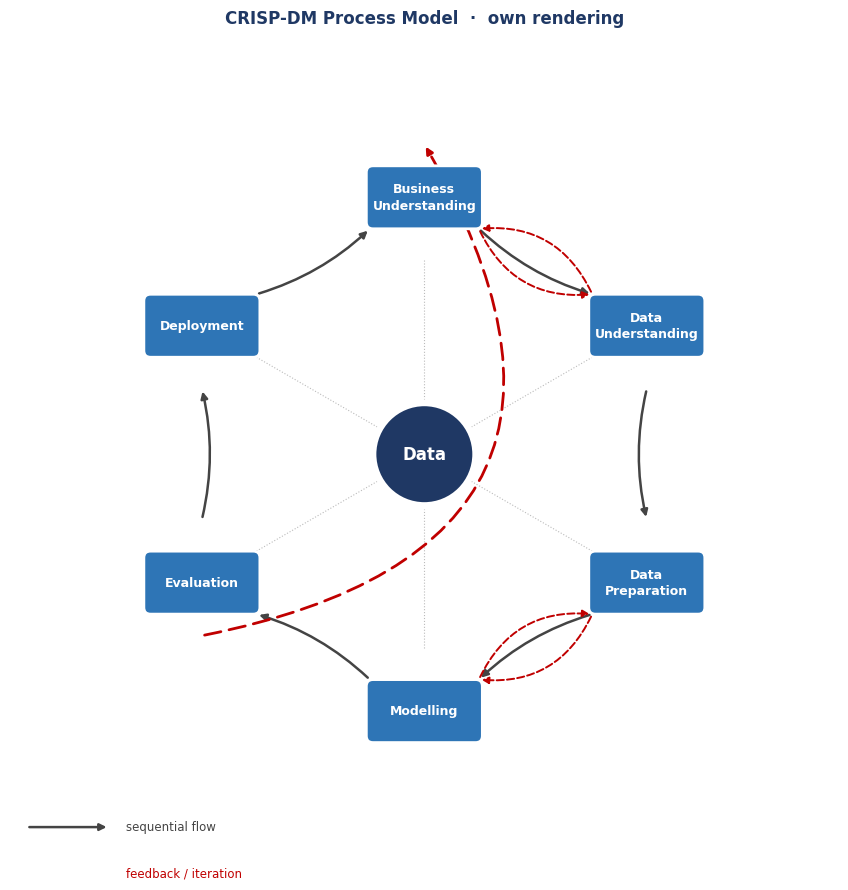

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(9, 9))
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect("equal")
ax.axis("off")
fig.patch.set_facecolor("white")

phases = [
    "Business\nUnderstanding",
    "Data\nUnderstanding",
    "Data\nPreparation",
    "Modelling",
    "Evaluation",
    "Deployment",
]

n = 6
ring_r = 1.55
# Start at top and go clockwise
angles = [np.pi / 2 - i * (2 * np.pi / n) for i in range(n)]
pos = np.array([(ring_r * np.cos(a), ring_r * np.sin(a)) for a in angles])

# Indices: 0=BU, 1=DU, 2=DP, 3=Mod, 4=Eval, 5=Deploy
BOX_W, BOX_H = 0.62, 0.30
PHASE_COL = "#2E75B6"
FEED_COL  = "#C00000"
MAIN_COL  = "#444444"


def box_edge(p_from, p_to, gap=0.38):
    """Return start/end points offset by gap from each box centre."""
    d = np.array(p_to) - np.array(p_from)
    dn = d / np.linalg.norm(d)
    return np.array(p_from) + dn * gap, np.array(p_to) - dn * gap


# ── Main clockwise sequential flow ──────────────────────────────────────
for i in range(n):
    s, e = box_edge(pos[i], pos[(i + 1) % n])
    ax.annotate("", xy=e, xytext=s,
                arrowprops=dict(arrowstyle="-|>", lw=1.8, color=MAIN_COL,
                                connectionstyle="arc3,rad=0.12"),
                zorder=2)

# ── Bidirectional feedback: BU ↔ DU (indices 0,1) ───────────────────────
for src, dst, rad in [(0, 1, 0.35), (1, 0, 0.35)]:
    s, e = box_edge(pos[src], pos[dst])
    ax.annotate("", xy=e, xytext=s,
                arrowprops=dict(arrowstyle="-|>", lw=1.4, color=FEED_COL,
                                linestyle="dashed",
                                connectionstyle=f"arc3,rad={rad}"),
                zorder=2)

# ── Bidirectional feedback: DP ↔ Modelling (indices 2,3) ────────────────
for src, dst, rad in [(2, 3, -0.35), (3, 2, -0.35)]:
    s, e = box_edge(pos[src], pos[dst])
    ax.annotate("", xy=e, xytext=s,
                arrowprops=dict(arrowstyle="-|>", lw=1.4, color=FEED_COL,
                                linestyle="dashed",
                                connectionstyle=f"arc3,rad={rad}"),
                zorder=2)

# ── Large outer loop: Evaluation → Business Understanding ────────────────
# Draw as a wide arc that sweeps around the outside of the diagram
eval_pt  = pos[4] + np.array([0.0, -0.32])   # bottom of Evaluation box
bu_pt    = pos[0] + np.array([0.0,  0.32])   # top of BU box
ax.annotate("", xy=bu_pt, xytext=eval_pt,
            arrowprops=dict(arrowstyle="-|>", lw=2.0, color=FEED_COL,
                            linestyle=(0, (6, 3)),
                            connectionstyle="arc3,rad=0.70"),
            zorder=2)

# ── Central "Data" node ─────────────────────────────────────────────────
ax.add_patch(mpatches.Circle((0, 0), 0.30,
                              facecolor="#1F3864", edgecolor="white",
                              linewidth=2.5, zorder=4))
ax.text(0, 0, "Data", ha="center", va="center",
        fontsize=12, color="white", fontweight="bold", zorder=5)

# Spokes from each phase box to the central Data node
for x, y in pos:
    d = np.array([x, y])
    dn = d / np.linalg.norm(d)
    start = d - dn * 0.38
    end   = dn * 0.33
    ax.plot([start[0], end[0]], [start[1], end[1]],
            color="#BBBBBB", lw=0.8, ls="dotted", zorder=1)

# ── Phase boxes ─────────────────────────────────────────────────────────
for phase, (x, y) in zip(phases, pos):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x - BOX_W / 2, y - BOX_H / 2), BOX_W, BOX_H,
        boxstyle="round,pad=0.04",
        facecolor=PHASE_COL, edgecolor="white",
        linewidth=2, zorder=3))
    ax.text(x, y, phase, ha="center", va="center",
            fontsize=9, color="white", fontweight="bold",
            linespacing=1.35, zorder=4)

# ── Legend ───────────────────────────────────────────────────────────────
lx, ly = -2.40, -2.25
ax.annotate("", xy=(lx + 0.50, ly), xytext=(lx, ly),
            arrowprops=dict(arrowstyle="-|>", lw=1.8, color=MAIN_COL))
ax.text(lx + 0.60, ly, "sequential flow", va="center", fontsize=8.5, color=MAIN_COL)

ax.annotate("", xy=(lx + 0.50, ly - 0.28), xytext=(lx, ly - 0.28),
            arrowprops=dict(arrowstyle="-|>", lw=1.4, color=FEED_COL,
                            linestyle="dashed"))
ax.text(lx + 0.60, ly - 0.28, "feedback / iteration", va="center",
        fontsize=8.5, color=FEED_COL)

ax.set_title(
    "CRISP-DM Process Model  ·  own rendering",
    fontsize=12, pad=12, color="#1F3864", fontweight="bold"
)
plt.tight_layout()
plt.savefig("crisp_dm_cycle.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 · Reproducibility & How to Run

### Environment

Install all dependencies from the repository root:

```bash
pip install -r requirements.txt
```

Python 3.10 or later is required. Key packages include `scikit-learn`, `lightgbm`, `catboost`, `optuna`, `imbalanced-learn`, `shap`, and `ucimlrepo`.

### Random Seed

Every notebook declares `SEED = 42` at the top and passes it to all stochastic operations (train/test split, cross-validation, model initialisation, Optuna sampler). No notebook introduces additional seeds.

### Data Access

Raw data is **not** stored in the repository. It is fetched automatically at runtime via the `ucimlrepo` package:

```python
from ucimlrepo import fetch_ucirepo
dataset = fetch_ucirepo(id=891)
```

An internet connection is required for the first run.

### Run Order

Run the numbered notebooks in order from the project root. Each notebook depends on the outputs of those preceding it, so the sequence must be respected.

### Repository Layout

```
diabetes-prediction-ml/
├── notebooks/          # one notebook per CRISP-DM step
├── src/
│   └── utils.py        # shared helpers
├── data/               # git-ignored; generated at runtime
│   ├── raw/
│   └── processed/
├── models/             # git-ignored; written during modelling
├── outputs/            # git-ignored; plots/CSVs per notebook
├── catboost_info/      # git-ignored; CatBoost training logs
├── requirements.txt
├── README.md
└── .gitignore
```

The directories `data/`, `models/`, `outputs/`, and `catboost_info/` are listed in `.gitignore` and are not tracked by Git.

In [2]:
import sys
import platform

SEED = 42

print(f"Python  : {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"SEED    : {SEED}")
print()

_packages = [
    ("numpy",           "numpy"),
    ("pandas",          "pandas"),
    ("scikit-learn",    "sklearn"),
    ("catboost",        "catboost"),
    ("imbalanced-learn","imblearn"),
    ("ucimlrepo",       "ucimlrepo"),
]

for display, import_name in _packages:
    try:
        mod = __import__(import_name)
        version = getattr(mod, "__version__", "installed (version unknown)")
        print(f"{display:<20}: {version}")
    except ImportError:
        print(f"{display:<20}: NOT INSTALLED")

Python  : 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
SEED    : 42

numpy               : 2.4.6


pandas              : 3.0.3


scikit-learn        : 1.8.0


catboost            : 1.2.10


imbalanced-learn    : 0.14.1
ucimlrepo           : installed (version unknown)


## References

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

U.S. Centers for Disease Control and Prevention (CDC). *Behavioral Risk Factor Surveillance System (BRFSS), 2015 Survey Data*. Atlanta, GA: CDC.

UCI Machine Learning Repository. *CDC Diabetes Health Indicators* (Dataset #891). Original curation by A. Teboul (Kaggle). https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators